## **Nearest Neighbor**



## Data Loading Logic

The CIFAR-10 dataset is stored in multiple batch files rather than a single file.  
Therefore, we first load each batch individually and then concatenate them into one complete training dataset.  
This step prepares the data in a structured format suitable for machine learning models.

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt


def load_batch(filename):
    with open(filename, "rb") as f:
        data = pickle.load(f, encoding="bytes")
        X = data[b"data"]
        y = data[b"labels"]
        return X, np.array(y)


def load_CIFAR10_local(path):
    X_train_list = []
    y_train_list = []

    for i in range(1, 6):
        X_batch, y_batch = load_batch(f"{path}/data_batch_{i}")
        X_train_list.append(X_batch)
        y_train_list.append(y_batch)

    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)

    X_test, y_test = load_batch(f"{path}/test_batch")

    return X_train, y_train, X_test, y_test

## Nearest Neighbor Model

This model does not learn parameters; it simply stores the training data.  
During prediction, it computes the distance between each test example and all training examples, then assigns the label of the closest (most similar) one.  

We can measure similarity using the L2 (Euclidean) distance:

$$
d_2(I_1, I_2) = \sqrt{\sum_p \left(I_1^p - I_2^p\right)^2}
$$

While simple, this approach is computationally expensive.

In [4]:
class NearestNeighbor(object):
  def __init__(self):
    pass

  def train(self, X, y):
    """ X is N x D where each row is an example. Y is 1-dimension of size N """
    # the nearest neighbor classifier simply remembers all the training data
    self.Xtr = X
    self.ytr = y

  def predict(self, X):
    """ X is N x D where each row is an example we wish to predict label for """
    num_test = X.shape[0]
    # lets make sure that the output type matches the input type
    Ypred = np.zeros(num_test, dtype = self.ytr.dtype)

    # loop over all test rows
    for i in range(num_test):
      # find the nearest training image to the i'th test image
      # using the L1 distance (sum of absolute value differences)
      distances = np.sum(np.abs(self.Xtr - X[i,:]), axis = 1)
      min_index = np.argmin(distances) # get the index with smallest distance
      Ypred[i] = self.ytr[min_index] # predict the label of the nearest example

    return Ypred

## Nearest Neighbor Classification Pipeline

In this section, we implement and evaluate a simple Nearest Neighbor classifier on the CIFAR-10 dataset.

First, we load the dataset and reshape each image from its original 3D format (32×32×3) into a 1D vector of length 3072. This step is necessary because the classifier operates on flat vectors rather than multi-dimensional images.

Next, we create a Nearest Neighbor model and "train" it by simply storing the training data and labels. Unlike other machine learning models, this method does not learn parameters.

During prediction, the model compares each test image to all training images using a distance metric (e.g., L1 distance). It then assigns the label of the most similar (closest) training example.

Finally, we evaluate the model by computing the classification accuracy, which is the fraction of correctly predicted labels on the test set.

Although this approach is simple and intuitive, it is computationally expensive because it requires comparing each test example with all training examples.

In [ ]:

# Load CIFAR-10 dataset (training and test data)
Xtr, Ytr, Xte, Yte = load_CIFAR10_local("/home/efeak/VSCodeProjects/cs231n/cifar-10-batches-py")

# Reshape images into rows (flatten 32x32x3 into 3072)
Xtr_rows = Xtr.reshape(Xtr.shape[0], 32 * 32 * 3)  # shape: (50000, 3072)
Xte_rows = Xte.reshape(Xte.shape[0], 32 * 32 * 3)  # shape: (10000, 3072)

# Create a Nearest Neighbor classifier
nn = NearestNeighbor()

# "Train" the model by storing training data
nn.train(Xtr_rows, Ytr)

# Predict labels for test data
Yte_predict = nn.predict(Xte_rows) #Yte_predict = nn.predict(Xte_rows[:100]) //faster result

# Compute accuracy (fraction of correct predictions)
accuracy = np.mean(Yte_predict == Yte)

# Print the result
print("accuracy: %f" % accuracy)

/tmp/ipykernel_1396/3243936598.py:8: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="bytes")


accuracy: 0.249200


## Nearest Neighbor with L2 Distance

In this section, we implement a Nearest Neighbor classifier using the L2 distance, also known as Euclidean distance.

The L2 distance measures the straight-line distance between two vectors. For images, each image is first flattened into a vector, and then the distance between pixel values is computed.

The formula for L2 distance is:

$$
d_2(I_1, I_2) = \sqrt{\sum_p (I_1^p - I_2^p)^2}
$$

The classifier predicts the label of the training image that has the smallest L2 distance to the test image.

In [6]:
class NearestNeighborL2(object):
    
    def __init__(self):
        pass

    def train(self, X, y):
        # Store the training data and labels
        self.Xtr = X
        self.ytr = y

    def predict(self, X):
        # Get the number of test examples
        num_test = X.shape[0]

        # Create an array to store predicted labels
        Ypred = np.zeros(num_test, dtype=self.ytr.dtype)

        # Loop over each test example
        for i in range(num_test):
            # Compute L2 distance between the test example and all training examples
            distances = np.sqrt(np.sum((self.Xtr - X[i, :]) ** 2, axis=1))

            # Find the index of the nearest training example
            min_index = np.argmin(distances)

            # Assign the label of the nearest training example
            Ypred[i] = self.ytr[min_index]

        return Ypred

# Train and Evaluate L2

In [8]:
# Normalize the data before training
# Note: Without normalization, the L2 accuracy was approximately 0.253500

# Compute the mean image from training data
mean_image = np.mean(Xtr_rows, axis=0)

# Subtract the mean from both training and test data
Xtr_rows = Xtr_rows - mean_image
Xte_rows = Xte_rows - mean_image


# Create a Nearest Neighbor classifier using L2 distance
nn_l2 = NearestNeighborL2()

# Train the classifier by storing the normalized training data
nn_l2.train(Xtr_rows, Ytr)

# Predict labels for the test data
Yte_predict_l2 = nn_l2.predict(Xte_rows)

# Compute L2 accuracy
accuracy_l2 = np.mean(Yte_predict_l2 == Yte)

# Print the result
print("L2 accuracy (with normalization): %f" % accuracy_l2)

L2 accuracy (with normalization): 0.353900


# L1 vs L2 Accuracy Comparison Code


In [9]:
# Create and train the L1 Nearest Neighbor classifier
#nn_l1 = NearestNeighbor()
#nn_l1.train(Xtr_rows, Ytr)

# Predict labels using L1 distance
#Yte_predict_l1 = nn_l1.predict(Xte_rows)

# Compute L1 accuracy
#accuracy_l1 = np.mean(Yte_predict_l1 == Yte)


# Create and train the L2 Nearest Neighbor classifier
#nn_l2 = NearestNeighborL2()
#nn_l2.train(Xtr_rows, Ytr)

# Predict labels using L2 distance
#Yte_predict_l2 = nn_l2.predict(Xte_rows)

# Compute L2 accuracy
#accuracy_l2 = np.mean(Yte_predict_l2 == Yte)


# Print both accuracies
print("L1 accuracy: %f" % accuracy) # accuracy gives L1 NN's accuracy rate 
print("L2 accuracy: %f" % accuracy_l2)

L1 accuracy: 0.249200
L2 accuracy: 0.353900


## k-Nearest Neighbor Classifier

The k-Nearest Neighbor classifier extends the basic Nearest Neighbor idea.

Instead of using only the single closest training example, the classifier finds the top k closest examples and lets them vote for the predicted label.

When \( k = 1 \), k-NN becomes the standard Nearest Neighbor classifier.

Using a larger value of \( k \) often makes the classifier more stable and less sensitive to outliers. This has a smoothing effect on the decision boundaries.

However, choosing \( k \) is important:
- Small \( k \): more sensitive to noise and outliers
- Large \( k \): smoother predictions, but may ignore local structure

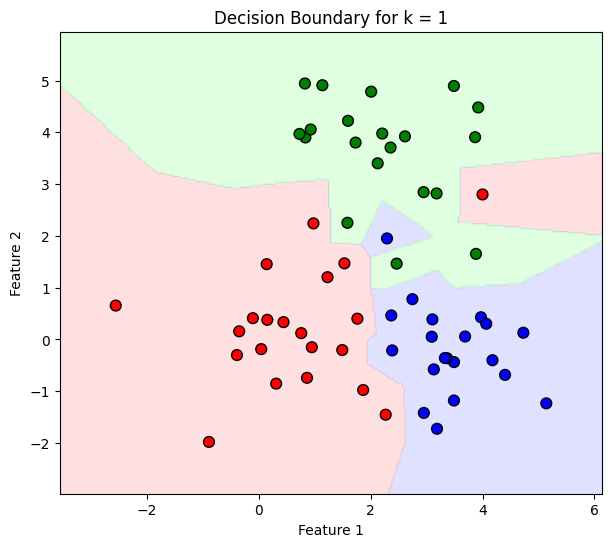

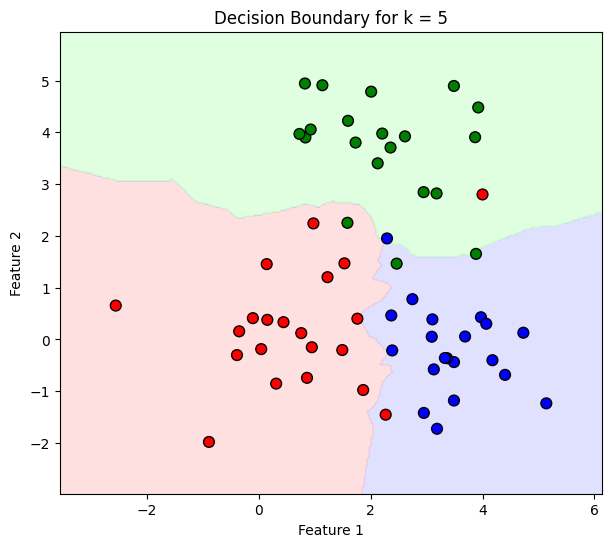

In [10]:

from matplotlib.colors import ListedColormap


# Create a small synthetic 2D dataset
np.random.seed(0)

# Generate three clusters of points
X_red = np.random.randn(20, 2) + np.array([0, 0])
X_blue = np.random.randn(20, 2) + np.array([4, 0])
X_green = np.random.randn(20, 2) + np.array([2, 3])

# Combine all points into one dataset
X_train_2d = np.vstack([X_red, X_blue, X_green])

# Create class labels for the points
y_train_2d = np.array([0] * 20 + [1] * 20 + [2] * 20)

# Add an outlier point to show the effect of k
X_outlier = np.array([[4, 2.8]])
y_outlier = np.array([0])

X_train_2d = np.vstack([X_train_2d, X_outlier])
y_train_2d = np.concatenate([y_train_2d, y_outlier])


class KNearestNeighbor2D(object):

    def __init__(self, k=1):
        # Store the number of neighbors
        self.k = k

    def train(self, X, y):
        # Store training data and labels
        self.Xtr = X
        self.ytr = y

    def predict(self, X):
        # Get the number of test points
        num_test = X.shape[0]

        # Create an array for predictions
        Ypred = np.zeros(num_test, dtype=self.ytr.dtype)

        # Predict each test point
        for i in range(num_test):
            # Compute L2 distances to all training points
            distances = np.sqrt(np.sum((self.Xtr - X[i, :]) ** 2, axis=1))

            # Get indices of the k closest points
            nearest_indices = np.argsort(distances)[:self.k]

            # Get labels of the k closest points
            nearest_labels = self.ytr[nearest_indices]

            # Count votes for each class
            votes = np.bincount(nearest_labels)

            # Choose the class with the most votes
            Ypred[i] = np.argmax(votes)

        return Ypred


def plot_decision_boundary(k):
    # Create classifier
    knn = KNearestNeighbor2D(k=k)

    # Train classifier
    knn.train(X_train_2d, y_train_2d)

    # Create a grid of points
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Flatten the grid into test points
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Predict class for each grid point
    Z = knn.predict(grid_points)

    # Reshape predictions back to grid shape
    Z = Z.reshape(xx.shape)

    # Create color maps
    background_cmap = ListedColormap(["#ffcccc", "#ccccff", "#ccffcc"])
    point_cmap = ListedColormap(["red", "blue", "green"])

    # Plot decision regions
    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, cmap=background_cmap, alpha=0.6)

    # Plot training points
    plt.scatter(
        X_train_2d[:, 0],
        X_train_2d[:, 1],
        c=y_train_2d,
        cmap=point_cmap,
        edgecolor="k",
        s=60
    )

    # Add title and labels
    plt.title(f"Decision Boundary for k = {k}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    # Show plot
    plt.show()


# Plot decision boundary for k = 1
plot_decision_boundary(k=1)

# Plot decision boundary for k = 5
plot_decision_boundary(k=5)